In [16]:
from PIL import Image
import numpy as np

def mel_image_to_vector(
    image_path,
    img_size=(128, 128)
):
    """
    Convert Mel spectrogram image into a fixed-length vector
    using PIL (no OpenCV required).
    """

    # Load image
    img = Image.open(image_path).convert("L")  # grayscale

    # Resize
    img = img.resize(img_size)

    # Convert to numpy
    img_array = np.array(img)

    # Normalize
    img_array = img_array / 255.0

    # Flatten
    vector = img_array.flatten()

    return vector


In [17]:
vec = mel_image_to_vector("updated-melspec/hungry/0a983cd2-0078-4698-a048-99ac01eb167a-1433917038889-1.7-f-04-hu.png")
print(vec.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\LOG IN\\Desktop\\ML-project\\notebooks\\updated-melspec\\hungry\\0a983cd2-0078-4698-a048-99ac01eb167a-1433917038889-1.7-f-04-hu.png'

In [25]:
import os

DATASET_PATH = "updated-melspec"

CLASSES = [
    "belly_pain",
    "burping",
    "discomfort",
    "hungry",
    "tired"
]

X = []
y = []

for label, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_dir):
        if file.endswith(".png"):
            img_path = os.path.join(class_dir, file)

            vector = mel_image_to_vector(img_path)

            X.append(vector)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (23, 16384)
y shape: (23,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


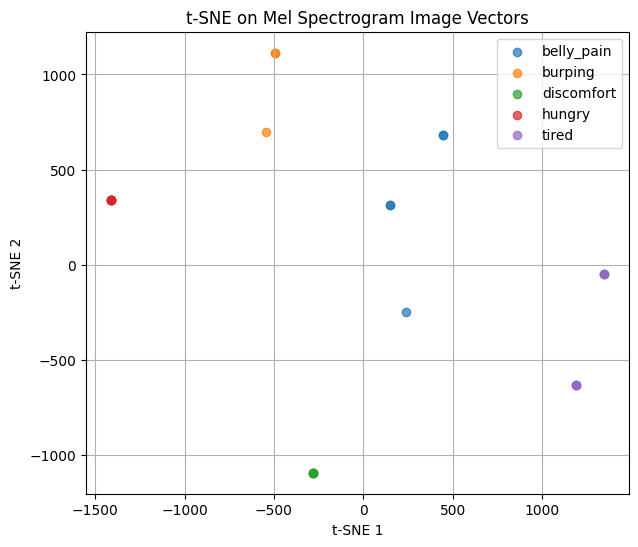

In [27]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=4,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))

for label, class_name in enumerate(CLASSES):
    idx = y == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=class_name,
        alpha=0.7
    )

plt.legend()
plt.title("t-SNE on Mel Spectrogram Image Vectors")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()
